# Observaciones sintéticas con JWST NIRSpec Prism

En esta celda se generaron observaciones sintéticas con **PandExo** para **TRAPPIST-1e**, asumiendo un **espectro de transmisión plano** (`planet.type = "constant"`) y una estrella anfitriona modelada con una atmósfera **PHOENIX**. La configuración base usada en `exo_dict` fue: magnitud estelar $J = 11.354$, $T_{\mathrm{eff}} = 2566\ \mathrm{K}$, $\log g = 5.2396$, metalicidad solar, radio estelar $R_* = 0.121\ R_{\odot}$, radio planetario $R_p = 0.081\ R_{\mathrm{Jup}}$, duración de tránsito de $0.9535\ \mathrm{h}$, nivel de saturación del $80\%$, línea de base total igual a tres veces la duración del tránsito y `noise_floor = 0`, de modo que no se impuso un piso instrumental adicional.

Para **NIRSpec Prism** se usó `subarray = "sub512"`, `ngroup = 6`, `noccultations = 1` y se conservaron los puntos entre $0.6$ y $5.3\ \mu\mathrm{m}$. En el mismo notebook también se corrió **MIRI LRS** con `ngroup = 175` y un recorte entre $5.0$ y $12.0\ \mu\mathrm{m}$. Los "ruidos" del espectro no se añadieron manualmente punto por punto, sino que se obtuvieron directamente de la simulación de PandExo mediante `jdi.run_pandexo(...)` y luego se extrajeron con `jpi.jwst_1d_spec(..., model=True, plot=False)`. De esa salida se tomó la profundidad de tránsito simulada (`depth`) y su incertidumbre espectral (`depth_err`), que representa el ruido esperado para cada bin. El ancho en longitud de onda de cada punto se estimó aparte como la mitad del gradiente entre bins vecinos (`0.5 * abs(gradient(wavelength))`), y finalmente los datos se ordenaron, limpiaron y filtraron antes de guardarse en formato compatible con POSEIDON.

Los productos finales se guardan en disco como archivos `.dat` con cuatro columnas (`wavelength`, `wavelength_err`, `depth`, `depth_err`) dentro de los directorios `POSEIDON_output/TRAPPIST-1e/pandexo_nirspec_prism_flat/` y `POSEIDON_output/TRAPPIST-1e/pandexo_miri_lrs_flat/`, lo que permite reutilizarlos después en el análisis y en la comparación con POSEIDON.


Running PandExo for: NIRSpec Prism
Detector configuration:
{'readout_pattern': 'nrsrapid', 'subarray': 'sub512', 'readmode': 'nrsrapid', 'ngroup': 6, 'nint': 1, 'nexp': 10}
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Saved file: c:\Proyectos\Astro\ExoFarm_MDwarfs\transmission spectra\notebooks\POSEIDON_output\TRAPPIST-1e\pandexo_nirspec_prism_flat\TRAPPIST-1e_flat_NIRSpec_Prism_1_transits.dat
Number of points: 403
Wavelength range kept: 0.602 - 5.298 um
Mean error: 379.68 ppm
Min diff(wl): 4.415511e-03
Min half-bin width: 2.207756e-03


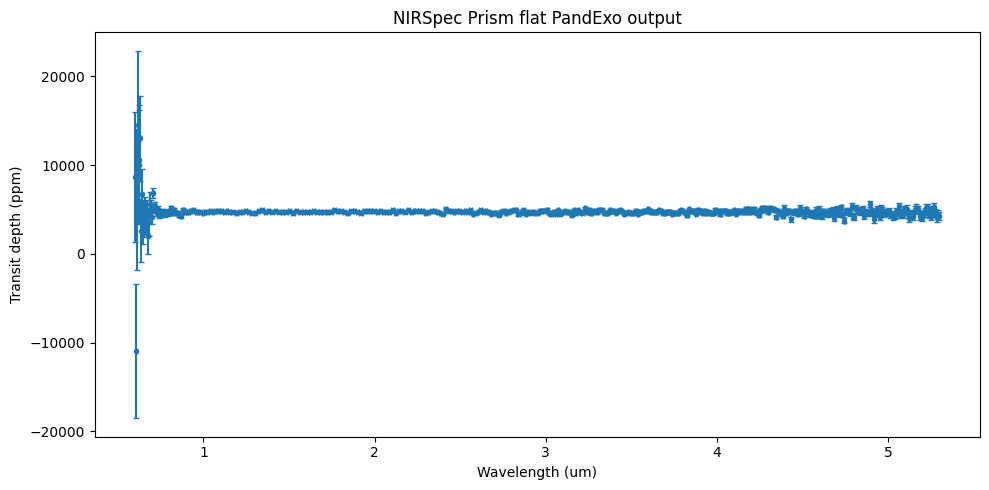


Running PandExo for: MIRI LRS
Detector configuration:
{'readout_pattern': 'fast', 'subarray': 'slitlessprism', 'readmode': 'fast', 'ngroup': 175, 'nint': 1, 'nexp': 10}
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Saved file: c:\Proyectos\Astro\ExoFarm_MDwarfs\transmission spectra\notebooks\POSEIDON_output\TRAPPIST-1e\pandexo_miri_lrs_flat\TRAPPIST-1e_flat_MIRI_LRS_1_transits.dat
Number of points: 247
Wavelength range kept: 5.021 - 12.000 um
Mean error: 1474.61 ppm
Min diff(wl): 1.689321e-02
Min half-bin width: 8.261898e-03


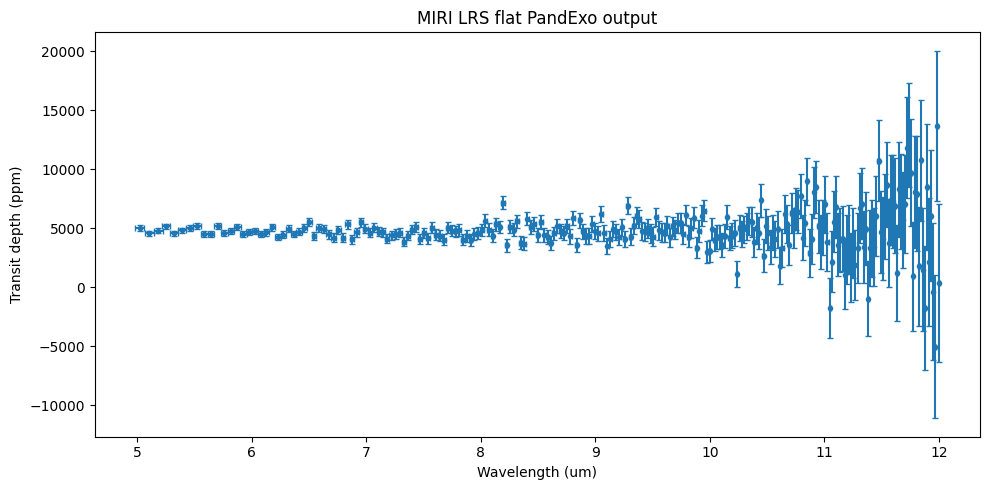


Done.
Prism file: c:\Proyectos\Astro\ExoFarm_MDwarfs\transmission spectra\notebooks\POSEIDON_output\TRAPPIST-1e\pandexo_nirspec_prism_flat\TRAPPIST-1e_flat_NIRSpec_Prism_1_transits.dat
MIRI file: c:\Proyectos\Astro\ExoFarm_MDwarfs\transmission spectra\notebooks\POSEIDON_output\TRAPPIST-1e\pandexo_miri_lrs_flat\TRAPPIST-1e_flat_MIRI_LRS_1_transits.dat


In [3]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandexo.engine.justdoit as jdi
import pandexo.engine.justplotit as jpi

warnings.filterwarnings("ignore")

# ============================================================
# Paths
# ============================================================
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "POSEIDON_output" / "TRAPPIST-1e"

PRISM_DIR = OUTPUT_DIR / "pandexo_nirspec_prism_flat"
MIRI_DIR = OUTPUT_DIR / "pandexo_miri_lrs_flat"

PRISM_DIR.mkdir(parents=True, exist_ok=True)
MIRI_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Base exo_dict for TRAPPIST-1e with a flat spectrum
# ============================================================
def build_trappist1e_flat_exo_dict(n_transits: int = 1) -> dict:
    """
    Build a PandExo exo_dict for TRAPPIST-1e using a flat transmission spectrum.
    """
    exo_dict = jdi.load_exo_dict()

    transit_duration_hr = 0.9535

    exo_dict["observation"].update(
        {
            "sat_level": 80,
            "sat_unit": "%",
            "baseline_unit": "total",
            "baseline": transit_duration_hr * 3.0 * 60.0 * 60.0,
            "noise_floor": 0,
            "noccultations": n_transits,
            # Leave native spectral sampling
            "R": None,
        }
    )

    exo_dict["star"].update(
        {
            "type": "phoenix",
            "mag": 11.354,
            "ref_wave": 1.25,   # J band
            "temp": 2566,
            "metal": 0.0,
            "logg": 5.2396,
            "radius": 0.121,
            "r_unit": "R_sun",
        }
    )

    exo_dict["planet"].update(
        {
            "type": "constant",
            "w_unit": "um",
            "f_unit": "rp^2/r*^2",
            "radius": 0.081,   # ~ TRAPPIST-1e in R_jup
            "r_unit": "R_jup",
            "transit_duration": transit_duration_hr * 60.0 * 60.0,
            "td_unit": "s",
        }
    )

    return exo_dict


# ============================================================
# Utility: robust half-bin widths
# ============================================================
def compute_half_bin_width(wavelength_um: np.ndarray) -> np.ndarray:
    """
    Compute positive half-bin widths from a wavelength grid.
    """
    if len(wavelength_um) < 2:
        return np.zeros_like(wavelength_um)

    return 0.5 * np.abs(np.gradient(wavelength_um))


# ============================================================
# Main runner
# ============================================================
def run_flat_pandexo_mode(
    instrument: str,
    output_dat_path: Path,
    n_transits: int = 1,
    ngroup: int | None = None,
    subarray: str | None = None,
    wl_min_keep: float | None = None,
    wl_max_keep: float | None = None,
    keep_err: float | None = None,
    plot: bool = False,
):
    """
    Run PandExo with a flat transmission spectrum and save a POSEIDON-compatible .dat file.

    Output columns:
    wavelength(um), wavelength_err(um), depth, depth_err
    """
    exo_dict = build_trappist1e_flat_exo_dict(n_transits=n_transits)
    inst_dict = jdi.load_mode_dict(instrument)

    # Update detector configuration only if requested and available
    if "configuration" in inst_dict and "detector" in inst_dict["configuration"]:
        if subarray is not None:
            inst_dict["configuration"]["detector"]["subarray"] = subarray
        if ngroup is not None:
            inst_dict["configuration"]["detector"]["ngroup"] = ngroup

    print("\n" + "=" * 60)
    print(f"Running PandExo for: {instrument}")
    if "configuration" in inst_dict and "detector" in inst_dict["configuration"]:
        print("Detector configuration:")
        print(inst_dict["configuration"]["detector"])

    result = jdi.run_pandexo(exo_dict, inst_dict)

    # Extract 1D spectrum
    wl_data, ydata, err_data = jpi.jwst_1d_spec(
        result,
        num_tran=n_transits,
        model=True,
        plot=False,
    )

    wl = np.asarray(wl_data[0], dtype=float)
    depth = np.asarray(ydata[0], dtype=float)
    err = np.asarray(err_data[0], dtype=float)

    # Clean
    valid = np.isfinite(wl) & np.isfinite(depth) & np.isfinite(err)
    wl = wl[valid]
    depth = depth[valid]
    err = err[valid]

    # Sort ascending to avoid negative xerr
    sort_idx = np.argsort(wl)
    wl = wl[sort_idx]
    depth = depth[sort_idx]
    err = err[sort_idx]

    # Positive half-widths
    half_width = compute_half_bin_width(wl)

    # Filtering
    keep = np.ones_like(wl, dtype=bool)

    if keep_err is not None:
        keep &= (err <= keep_err)

    if wl_min_keep is not None:
        keep &= (wl >= wl_min_keep)

    if wl_max_keep is not None:
        keep &= (wl <= wl_max_keep)

    wl_out = wl[keep]
    half_width_out = half_width[keep]
    depth_out = depth[keep]
    err_out = err[keep]

    if len(wl_out) == 0:
        raise RuntimeError(
            f"No data points survived filtering for {instrument}. "
            "Try relaxing wl_min_keep, wl_max_keep, or keep_err."
        )

    data_out = np.column_stack([wl_out, half_width_out, depth_out, err_out])

    np.savetxt(
        output_dat_path,
        data_out,
        header="wavelength(um) wavelength_err(um) depth depth_err",
        fmt="%.8e",
    )

    print(f"Saved file: {output_dat_path}")
    print(f"Number of points: {len(wl_out)}")
    print(f"Wavelength range kept: {wl_out.min():.3f} - {wl_out.max():.3f} um")
    print(f"Mean error: {1e6 * np.mean(err_out):.2f} ppm")

    if len(wl_out) > 1:
        print(f"Min diff(wl): {np.min(np.diff(wl_out)):.6e}")
    print(f"Min half-bin width: {np.min(half_width_out):.6e}")

    if plot:
        plt.figure(figsize=(10, 5))
        plt.errorbar(
            wl_out,
            depth_out * 1e6,
            xerr=half_width_out,
            yerr=err_out * 1e6,
            fmt="o",
            ms=3,
            capsize=2,
        )
        plt.xlabel("Wavelength (um)")
        plt.ylabel("Transit depth (ppm)")
        plt.title(f"{instrument} flat PandExo output")
        plt.tight_layout()
        plt.show()

    return {
        "instrument": instrument,
        "wavelength_um": wl_out,
        "wavelength_err_um": half_width_out,
        "depth": depth_out,
        "error": err_out,
        "output_path": output_dat_path,
        "raw_result": result,
    }


# ============================================================
# Run examples
# ============================================================
N_TRANSITS_BASE = 1

# ----------------------------
# 1) NIRSpec Prism
# ----------------------------
prism_result = run_flat_pandexo_mode(
    instrument="NIRSpec Prism",
    output_dat_path=PRISM_DIR / f"TRAPPIST-1e_flat_NIRSpec_Prism_{N_TRANSITS_BASE}_transits.dat",
    n_transits=N_TRANSITS_BASE,
    subarray="sub512",
    ngroup=6,
    wl_min_keep=0.6,
    wl_max_keep=5.3,
    keep_err=None,
    plot=True,
)

# ----------------------------
# 2) MIRI LRS
# ----------------------------
miri_result = run_flat_pandexo_mode(
    instrument="MIRI LRS",
    output_dat_path=MIRI_DIR / f"TRAPPIST-1e_flat_MIRI_LRS_{N_TRANSITS_BASE}_transits.dat",
    n_transits=N_TRANSITS_BASE,
    ngroup=175,
    wl_min_keep=5.0,
    wl_max_keep=12.0,
    keep_err=None,
    plot=True,
)

print("\nDone.")
print("Prism file:", prism_result["output_path"])
print("MIRI file:", miri_result["output_path"])